In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

import os
import json
from PIL import Image
from matplotlib import pyplot as plt

from tqdm import tqdm

In [4]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

## Создание датасета

In [26]:
class SunDataset(data.Dataset):
    def __init__(self, path, train=True, transforms=None):
        self.path = os.path.join(path, "train" if train else "test")
        self.transforms = transforms

        with open(os.path.join(self.path, "format.json"), 'r') as file:
            js_file = json.load(file)
        
        self.length = len(js_file.keys())
        self.targets = tuple(js_file.values())
        self.data = tuple(js_file.keys())

    def __getitem__(self, item):
        full_path = os.path.join(self.path, self.data[item])
        img = Image.open(full_path).convert('RGB')

        if self.transforms:
            img = self.transforms(img)

        return img, torch.tensor(self.targets[item], dtype=torch.float32)
    
    def __len__(self):
        return self.length

In [27]:
transf = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32, scale=True)])

In [28]:
d_train = SunDataset("../datasets/dataset_reg", transforms=transf, train=True)
data_train = data.DataLoader(d_train, batch_size=32, shuffle=True)

## Создание модели

In [29]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=32, out_channels=8, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(4096, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)
model = model.to(device)
next(model.parameters()).device

device(type='mps', index=0)

In [30]:
optimizer = optim.Adam(params=model.parameters(), lr=0.01, weight_decay=0.001)
loss_func = nn.MSELoss().to(device)

epochs = 5

In [31]:
model.train()
for _e in range(epochs):
    loss_mean = 0
    loss_count = 0

    train_bar = tqdm(data_train, leave=True)
    for x_train, y_train in train_bar:
        x_train, y_train = x_train.to(device), y_train.to(device)

        pred = model(x_train)
        loss = loss_func(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_count += 1
        loss_mean = 1/loss_count * loss.item() + (1 - 1/loss_count) * loss_mean
        train_bar.set_description(f"Epoch [{_e+1}/{epochs}]: loss_mean={loss_mean:.3f}")

Epoch [5/5]: loss_mean=17.271: 100%|██████████| 313/313 [00:33<00:00,  9.25it/s]


In [32]:
st = model.state_dict()
torch.save(st, "model_regsun.tar")

## Тестирование модели

In [ ]:
d_test = SunDataset("../datasets/dataset_reg", transforms=transf, train=False)
data_test = data.DataLoader(d_train, batch_size=len(d_test), shuffle=False)

In [35]:
model.eval()

for x_test, y_test in data_test:
    with torch.no_grad():
        x_test, y_test = x_test.to(device), y_test.to(device)
        pred = model(x_test)
        loss = loss_func(pred, y_test)
loss

tensor(7.5202, device='mps:0')

## Смотрим на предсказания на картинке

In [39]:
path = "../datasets/dataset_reg/test"
img_num = 1
img_path = os.path.join(path, f"sun_reg_{img_num}.png")

In [45]:
tranforms = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32, scale=True)])
img = Image.open(img_path).convert("RGB")
img_tf = tranforms(img).unsqueeze(0)

In [46]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=32, out_channels=8, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(in_channels=8, out_channels=4, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(4096, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

In [ ]:
weights = torch.load("models/model_regsun.tar")
model.load_state_dict(weights)

<All keys matched successfully>

In [52]:
pred = model(img_tf)
p = pred.detach().squeeze().numpy()
p

array([196.76009,  39.78094], dtype=float32)

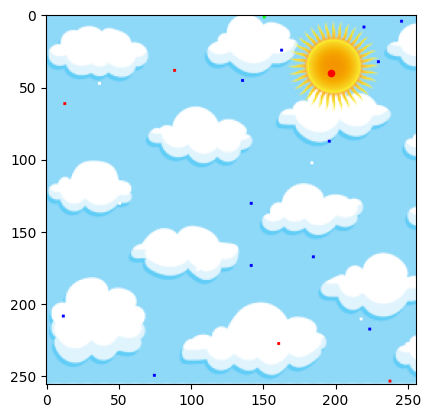

In [54]:
plt.imshow(img)
plt.scatter(p[0], p[1], c='r', s=20)
plt.show()